| Name | Gonzaga, Aloysius Q. |
|---|---|
| ID Number | 2023100147 |
| Section | CEA_CpE_2A_STEM |

# Coding Assignment 1: Exploratory Data Analysis for Neural Networks

## Objectives
By the end of this activity, you will be able to:
1. Load and inspect a real-world dataset.
2. Apply the full range of EDA visualization techniques covered in class.
3. Interpret each plot in the context of preparing data for a neural network.
4. Justify preprocessing decisions (scaling, encoding, outlier handling) based on visual evidence.

## Dataset
**Dataset:** Pima Indians Diabetes Dataset


**Description:** 768 patient records with 8 numeric medical predictor features and a binary target (`Outcome`: 1 = diabetic, 0 = non-diabetic). It is commonly used to build a neural network binary classifier, and it contains realistic data-quality issues (disguised missing values, skewed distributions, outliers) that make it excellent for EDA practice.

**Direct download (already wired into the loader cell below):**
`https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv`

Run the cell below first — do not change it.

Write your program in each code cell as needed. Write your observations and explanations in each markdown cell (create one if none is provided).

<font color="red">Create a copy of this notebook and edit that copy. Do not make any alterations in this notebook. Anyone who will be caught editing this notebook will automatically marked zero.</font>

In [133]:
# Dataset Loader (please do not modify this part)
import pandas as pd

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, names=columns)

# NOTE: In this dataset, 0 is used as a placeholder for missing values in several medical columns. Part of your task is to identify and handle this.
print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [137]:
#The following libraries are used for data analysis and visualization, as well as for building and evaluating machine learning models.
# If you need more packages, you can install them using pip.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

try:
    import missingno as msno
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "missingno", "--quiet"])
    import missingno as msno

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


---
## Task 1 — Data Overview (15 pts)
Display the shape, data types, and summary statistics of the dataset. Write a 2–3 sentence observation about what you notice (e.g., ranges, suspicious zero values).


In [133]:
#Task 1

print("=" * 40)
print("Dimensions (row, column): " + str(df.shape))
print("=" * 40)
print("\n")


print("=" * 40)
print("First 10 rows: ")
print("=" * 40)
display(df.head(10))

print("=" * 40)
print("Data types of the Dataset:")
print("=" * 40)
print(df.dtypes)

print("\n")
print("=" * 40)
print("Summary statistics of the Dataset:")
print("=" * 40)
display(df.describe())


Dimensions (row, column): (768, 9)


First 10 rows: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Data types of the Dataset:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


Summary statistics of the Dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Observation: 

On the first table, we can see 9 columns of data and displaying only 10 data rows from a total of 768 data rows/observations in the whole csv. In the table, we can observe that there are some missing values(except on Pregnancies and Outcome) such as insulin having the most missing values and some on Skin thickness. These missing values could greatly impact the accuracy and statistics of this dataset, further shown in table 3.

Most data included on the csv file comes in an integer data type, while BMI and DiabetesPedigreeFunction have a floating data type in order to show accurate BMI and DPF values.

The summary statistics of the data set show the mean, standard deviation, minimum, percentile and max values, with complete and data based calculations, however we can see that the missing values affected the clarity and accuracy of the data with the minimum value being mostly zeros, except the Pregnancies and the Outcome data which has the minimum value of 0.

These missing data points are later approximated and substituted by the mean of the values, shown and applied in Task 2: Missing Value Analysis.






.



**Observation:**
Explain your observation based from the summary statistics you've shown above.

## Task 2 — Missing Value Analysis (15 pts)
The columns `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` use `0` to represent missing data, which is not medically possible. Replace these zeros with `NaN`, then produce:
- A **missingno matrix** plot
- A **missingno bar** plot
- A **heatmap** of missing values

Interpret the results: which columns have the most missing data?


Amount of Missing Values in Each Column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Missing Value Percentage in Each Column:


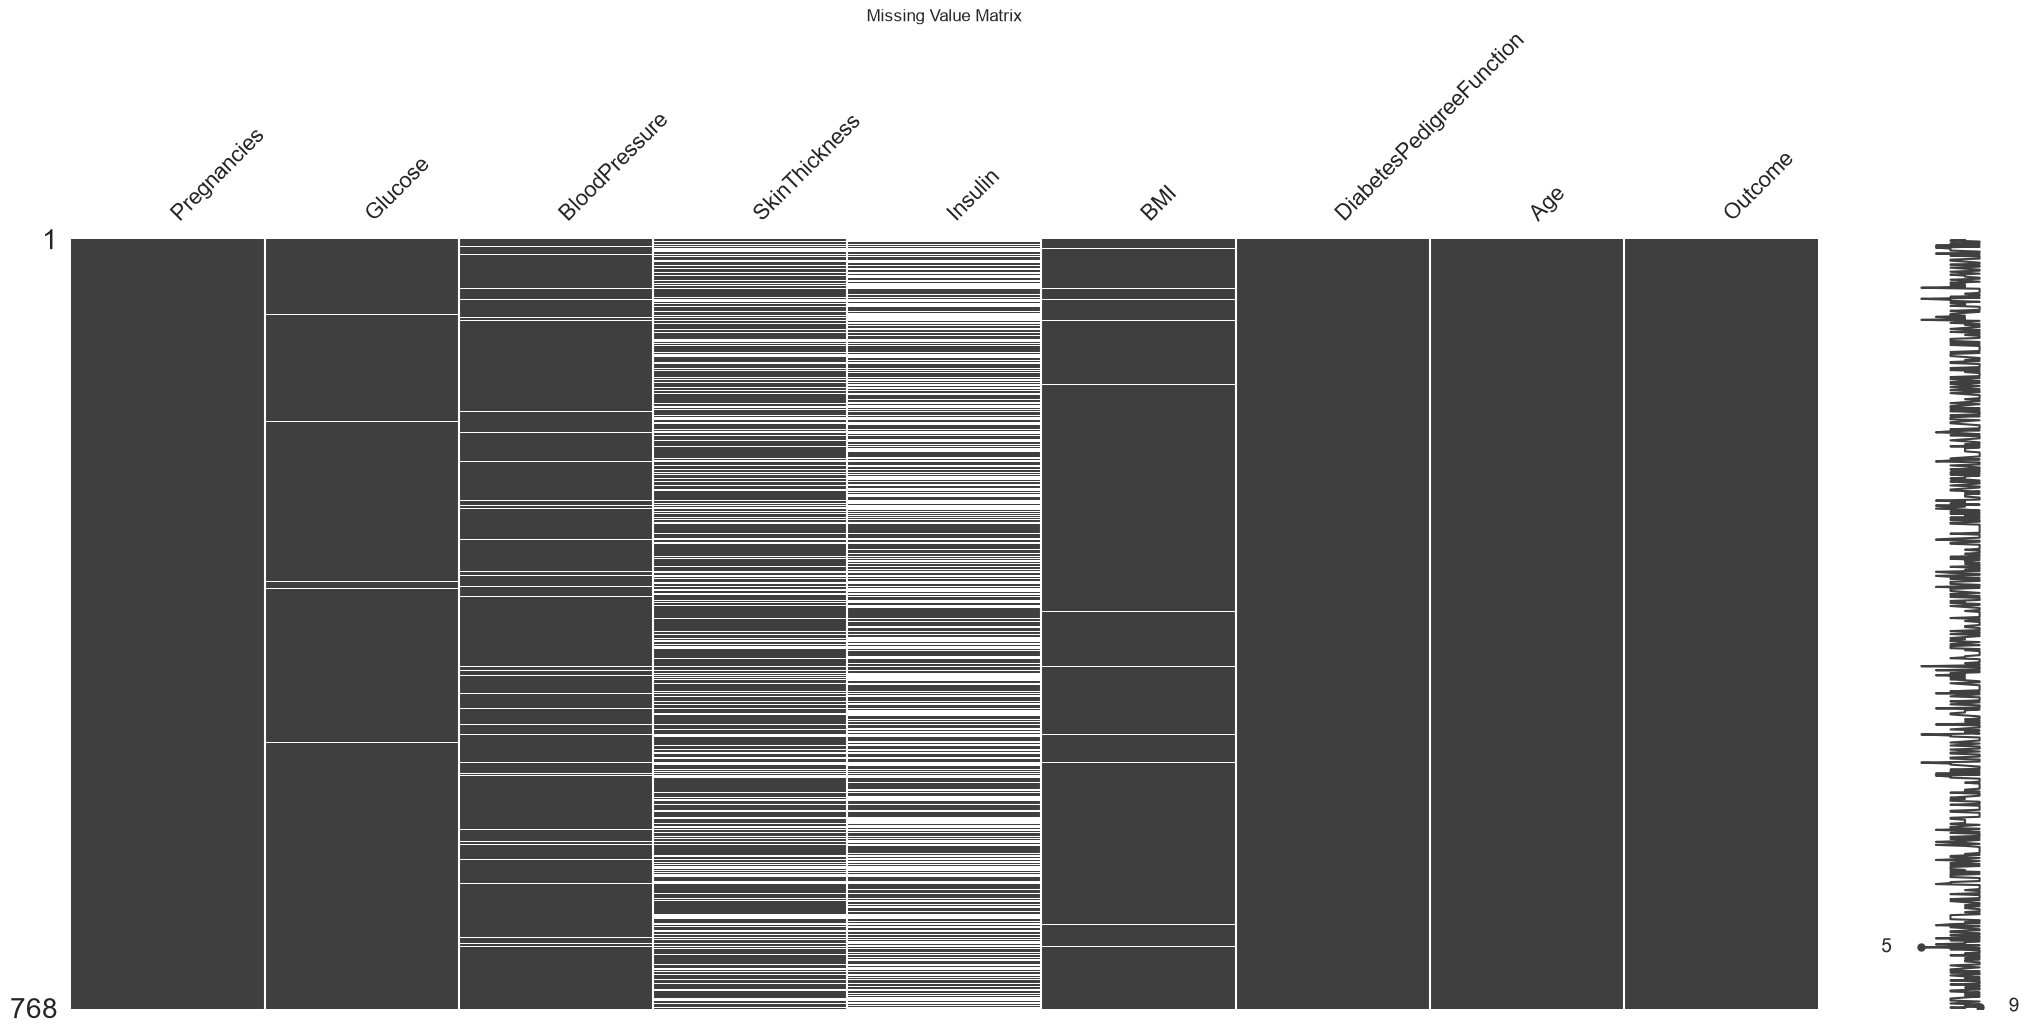

Missing Value Bar Chart:


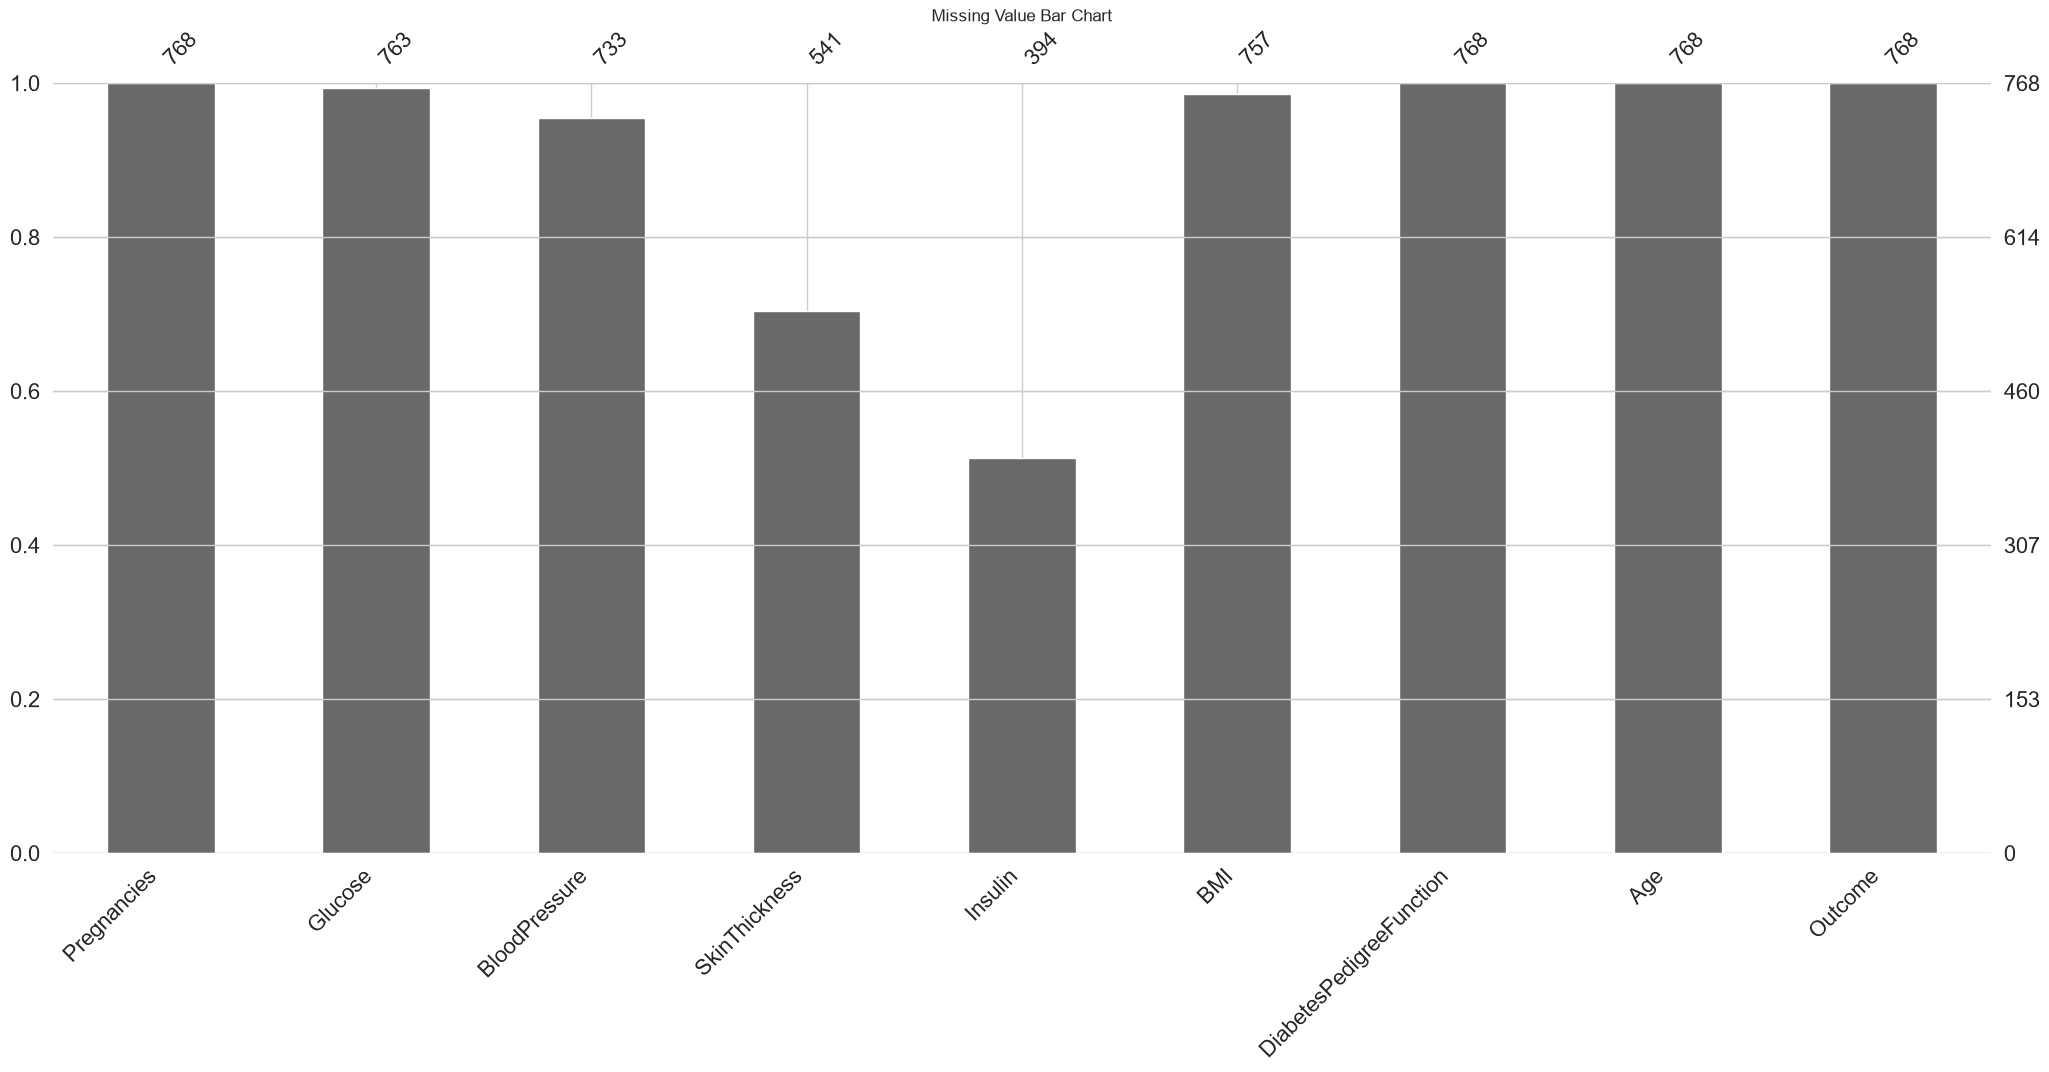

Missing Value Heatmap:


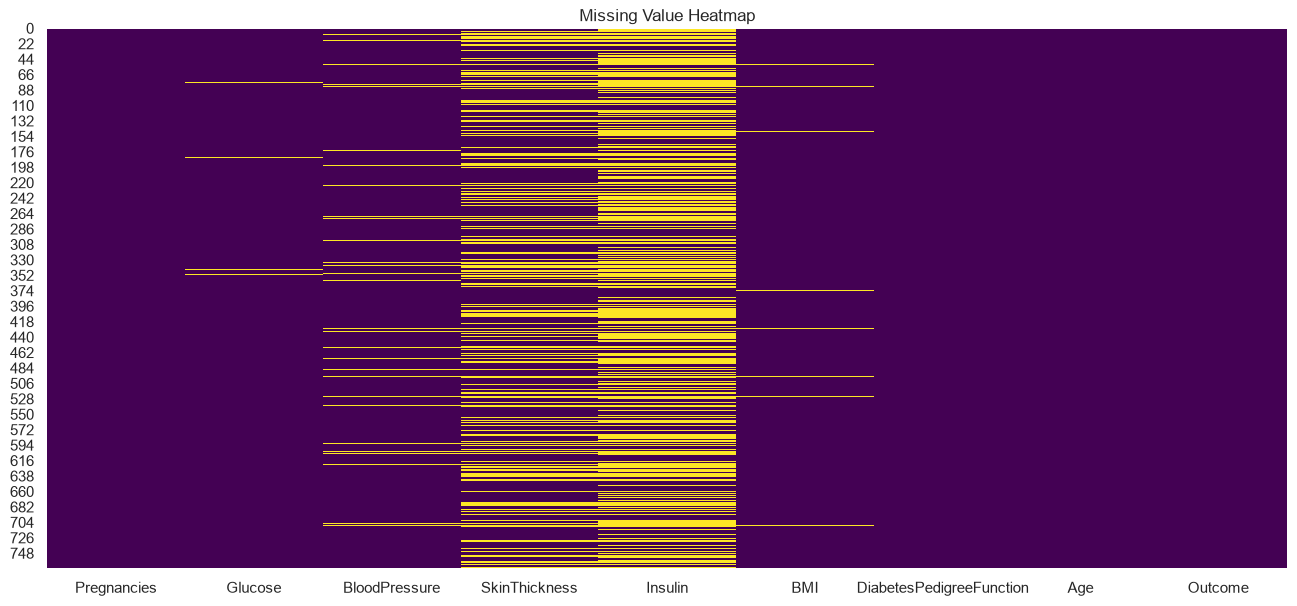

In [136]:
#Task 2

missing_values = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[missing_values] = df[missing_values].replace(0, np.nan)

print("=" * 40)
print("Amount of Missing Values in Each Column:")
print("=" * 40)
print(df.isnull().sum())
print("\n")


print("=" * 40)
print("Missing Value Percentage in Each Column:")
print("=" * 40)
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()



print("=" * 40)
print("Missing Value Bar Chart:")
print("=" * 40)
msno.bar(df)
plt.title("Missing Value Bar Chart")
plt.show()


print("=" * 40)
print("Missing Value Heatmap:")
print("=" * 40)
plt.figure(figsize=(16,7))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()


Observation:

   We can observe that there are numerous missing values in the dataset. Among all variables, it is observed that insulin has the most missing values, followed by SkinThickness.

   Based on the Heatmap and the matrix plot, we can see that insulin has the highest number of missing values displayed in ranges of the shade yellow, together with SkinThickness and Pregnancies. We can further prove through the Bar Chart graph that insulin has the least amount of data due to the massive amount of missing values in the dataset.

   The table of missing values above provides the specific counts: Insulin has 374 missing values, followed by SkinThickness with 227 missing values, while the rest have fewer than 50 missing values combined.



## Task 3 — Univariate Analysis (25 pts)
For at least 3 numeric features, produce:
- **Histogram**
- **KDE plot**
- **Box (whisker) plot**
- **Violin plot**
- **Q-Q plot**

Identify which features are skewed and which contain outliers.


* ### Histogram for the selected features

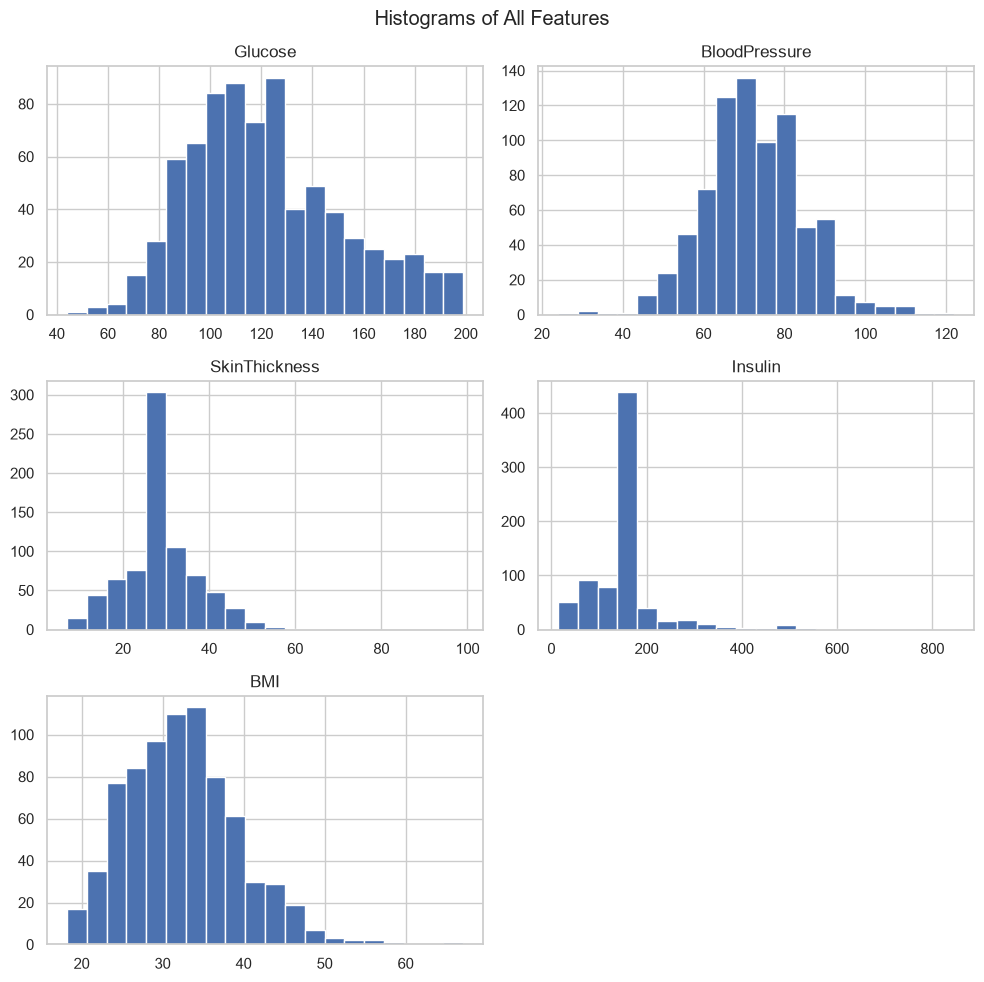

In [137]:
#Task 3

# Selects the features to analyze and fill missing values with the mean
selected_features = ["Glucose", "BloodPressure",  "SkinThickness", "Insulin", "BMI"]
df[selected_features] = df[selected_features].fillna(df[selected_features].mean())

# Histograms for each selected feature:
df[selected_features].hist(bins=20, figsize=(10, 10))
plt.suptitle("Histograms of All Features")
plt.tight_layout()
plt.show()



* ### KDE Plot for selected features:

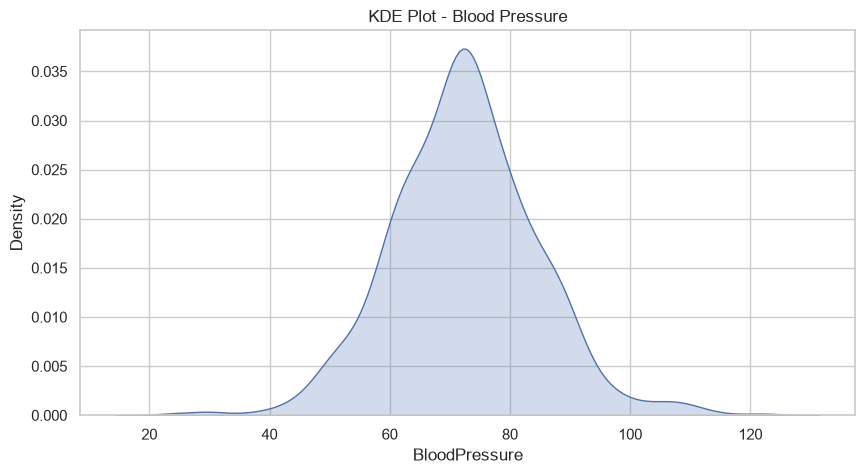

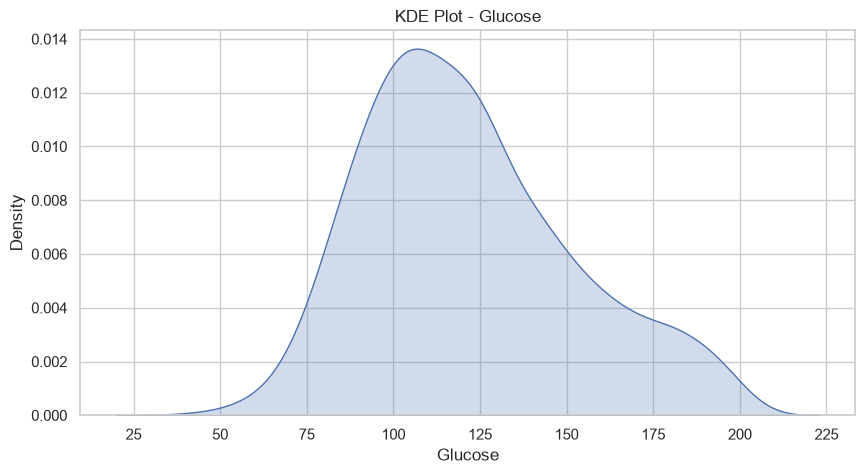

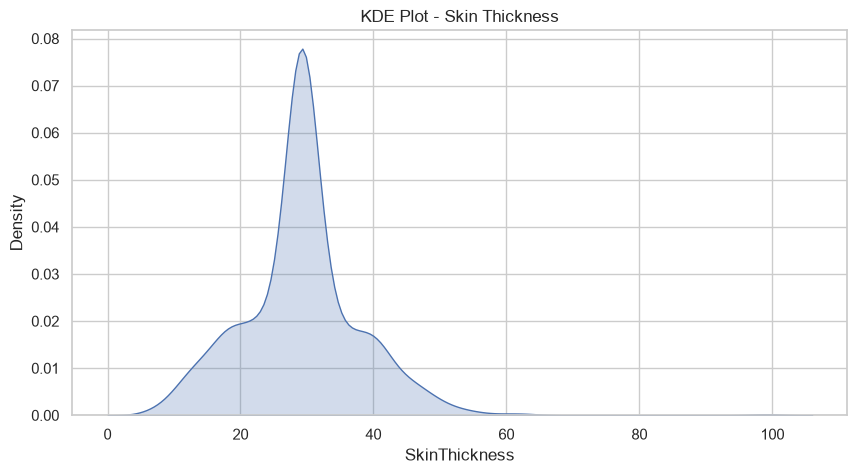

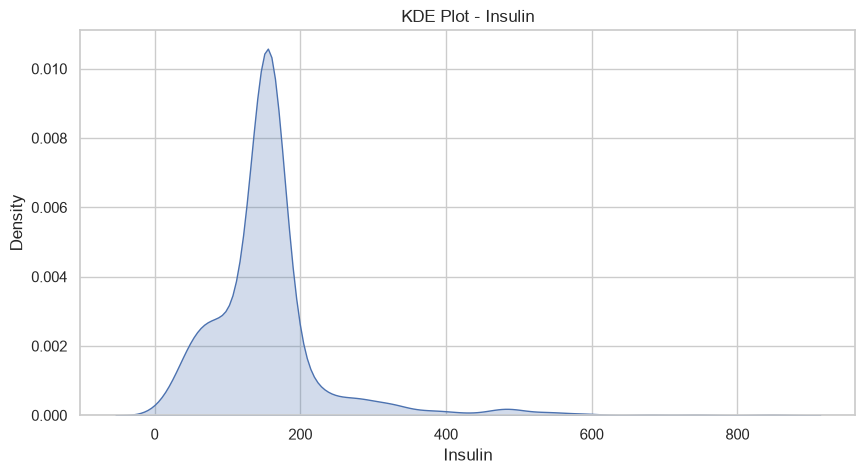

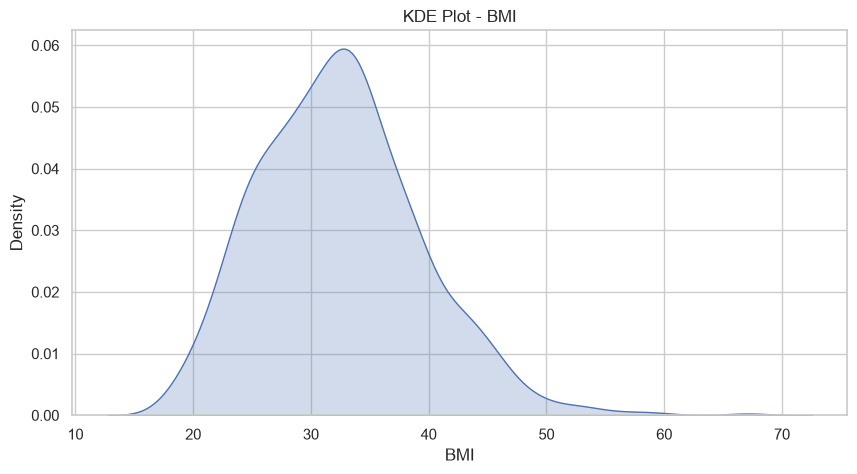

In [132]:
#KDE plot for each selected feature: 
plt.figure(figsize=(10,5))
sns.kdeplot(df["BloodPressure"], fill=True)
plt.title("KDE Plot - Blood Pressure")
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(df["Glucose"], fill=True)
plt.title("KDE Plot - Glucose")
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(df["SkinThickness"], fill=True)
plt.title("KDE Plot - Skin Thickness")
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(df["Insulin"], fill=True)
plt.title("KDE Plot - Insulin")
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(df["BMI"], fill=True)
plt.title("KDE Plot - BMI")
plt.show()


* ### Box(Whisker) and Violin Plot of the selected features:

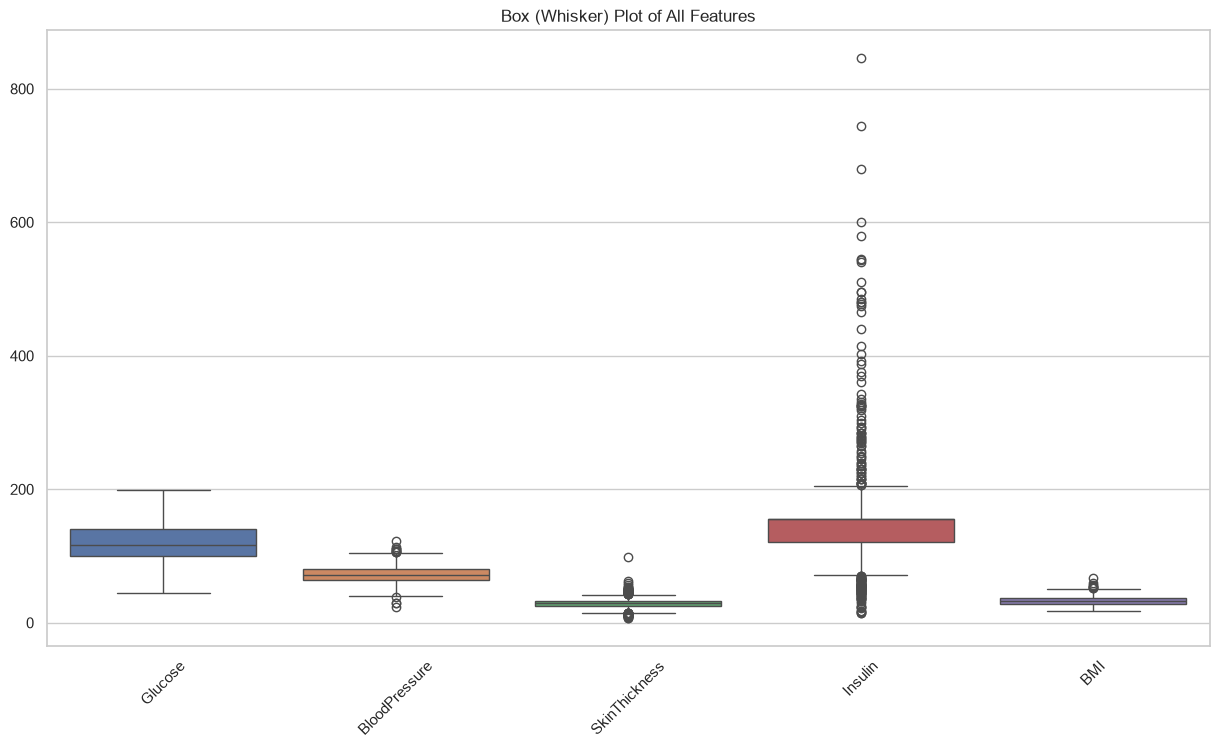

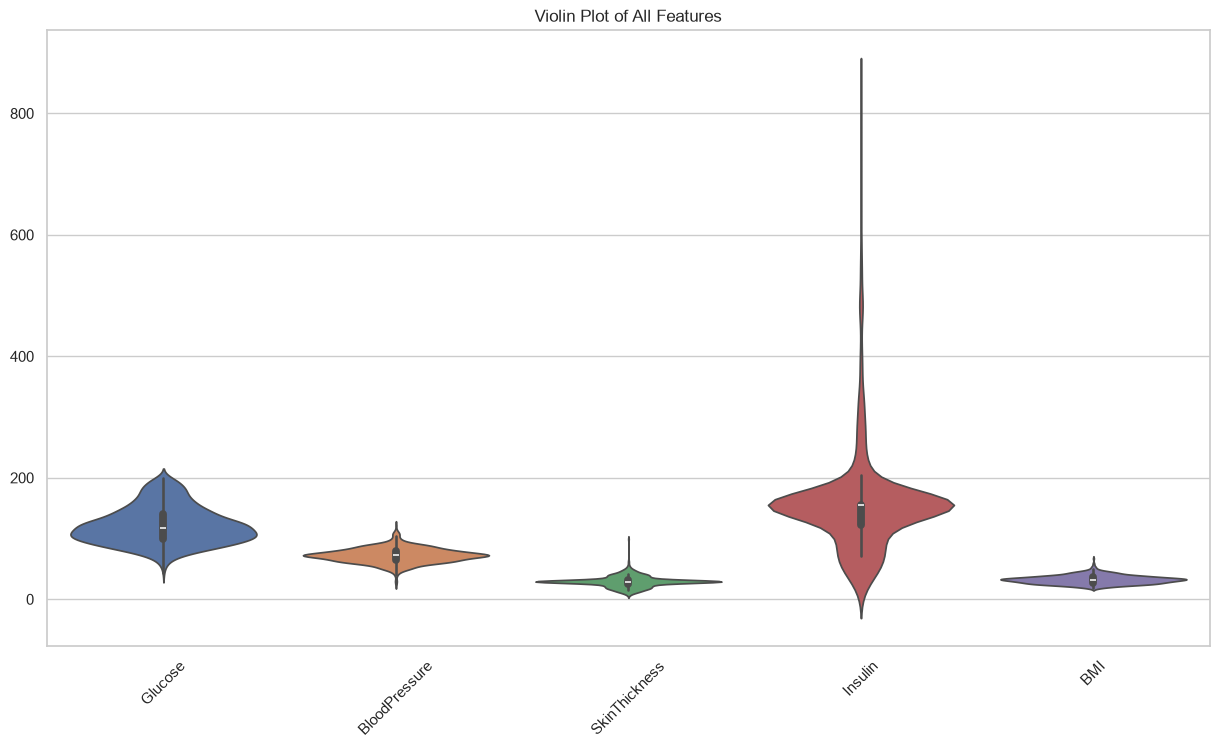

In [139]:
#  Box (Whisker) Plot for each selected feature:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[selected_features])
plt.xticks(rotation=45)
plt.title("Box (Whisker) Plot of All Features")
plt.show()

# Violin Plot for each selected feature:
plt.figure(figsize=(15,8))
sns.violinplot(data=df[selected_features])
plt.xticks(rotation=45)
plt.title("Violin Plot of All Features")
plt.show()


* ### Q-Q Plot for each selected features:

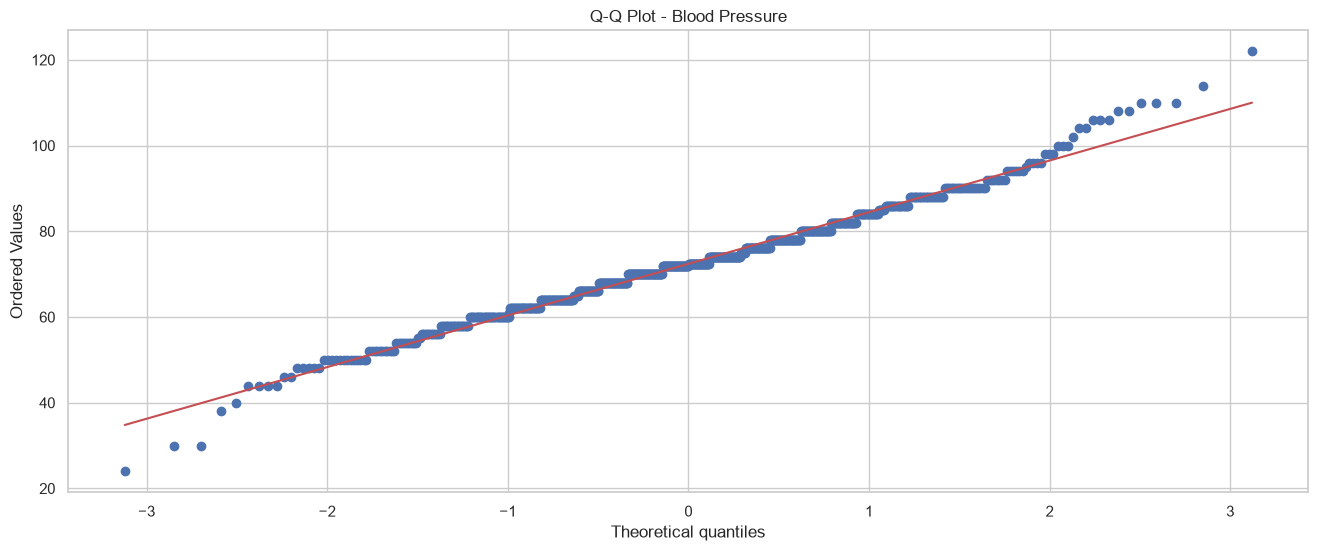

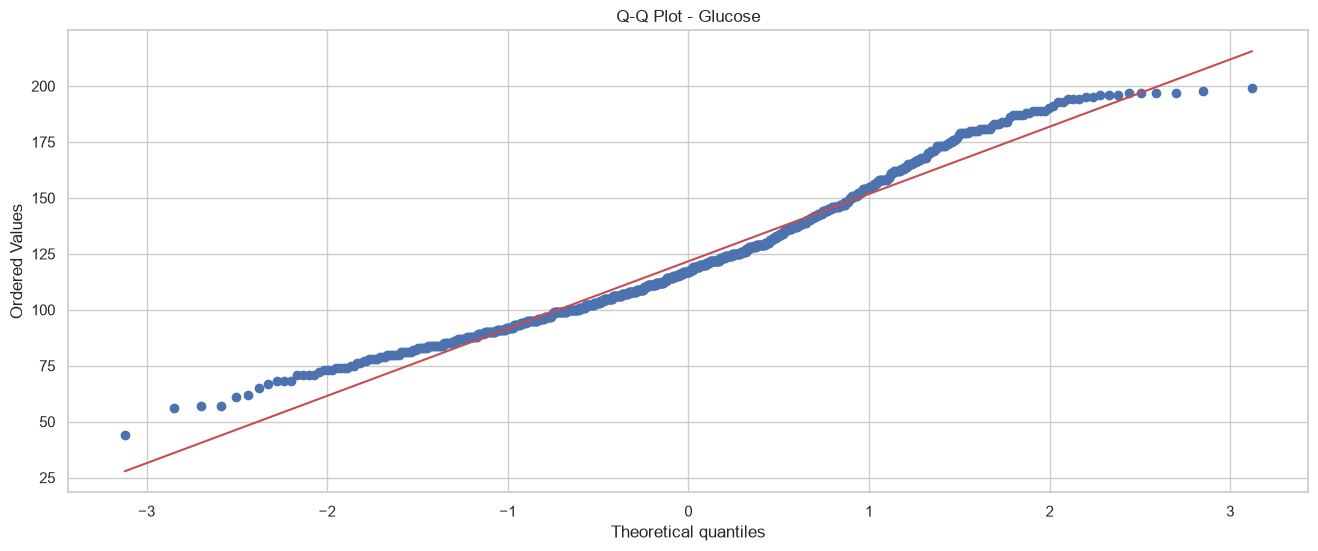

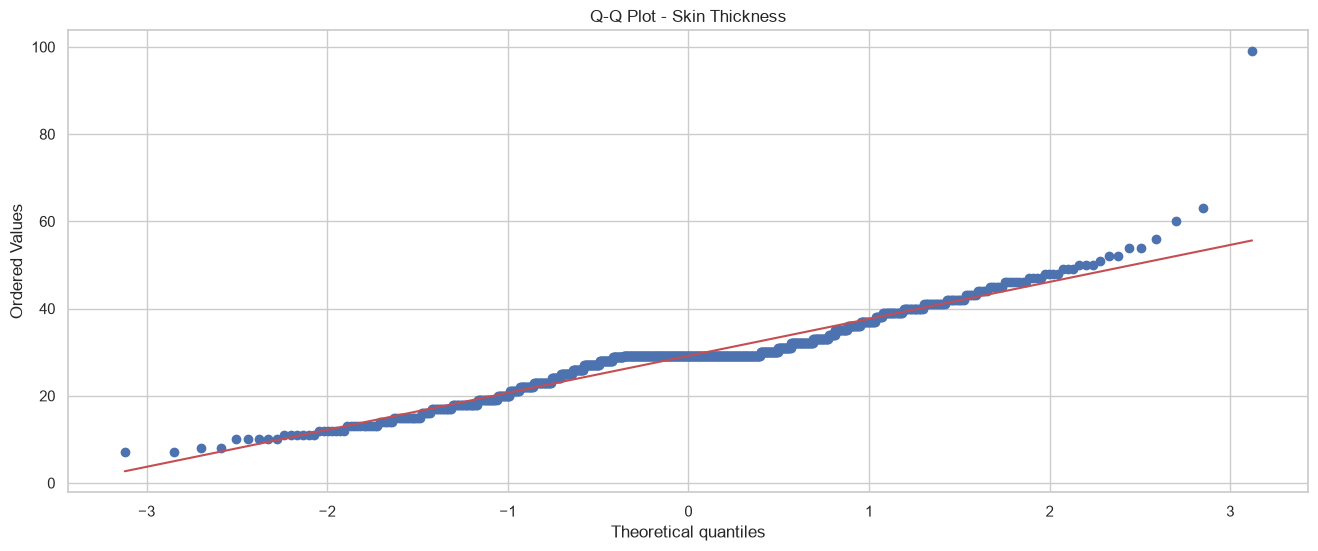

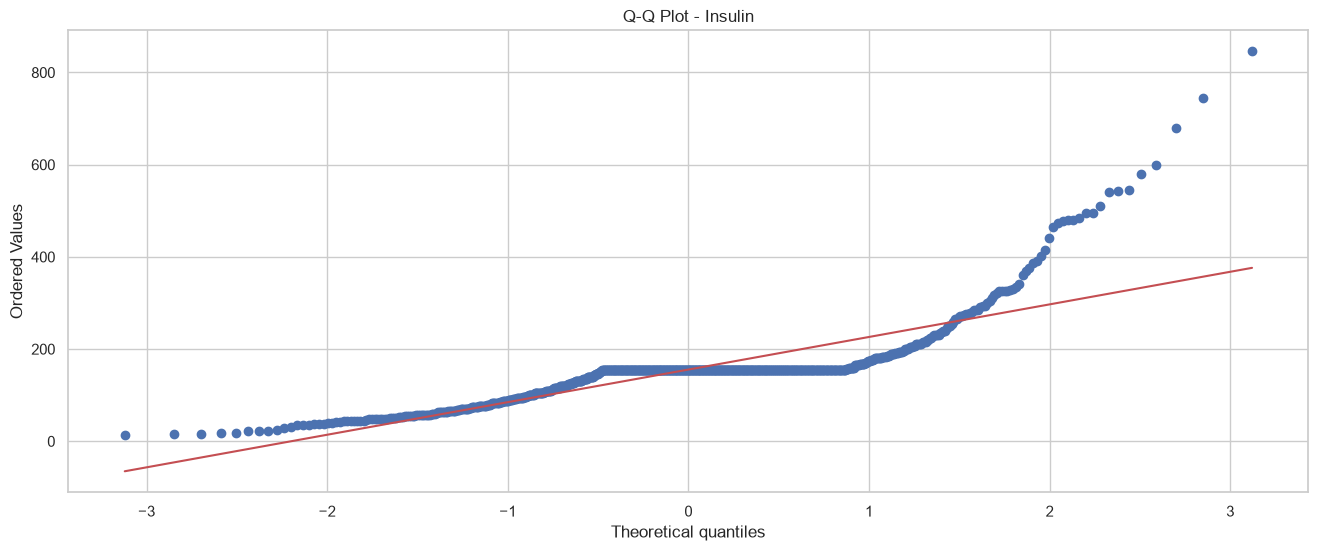

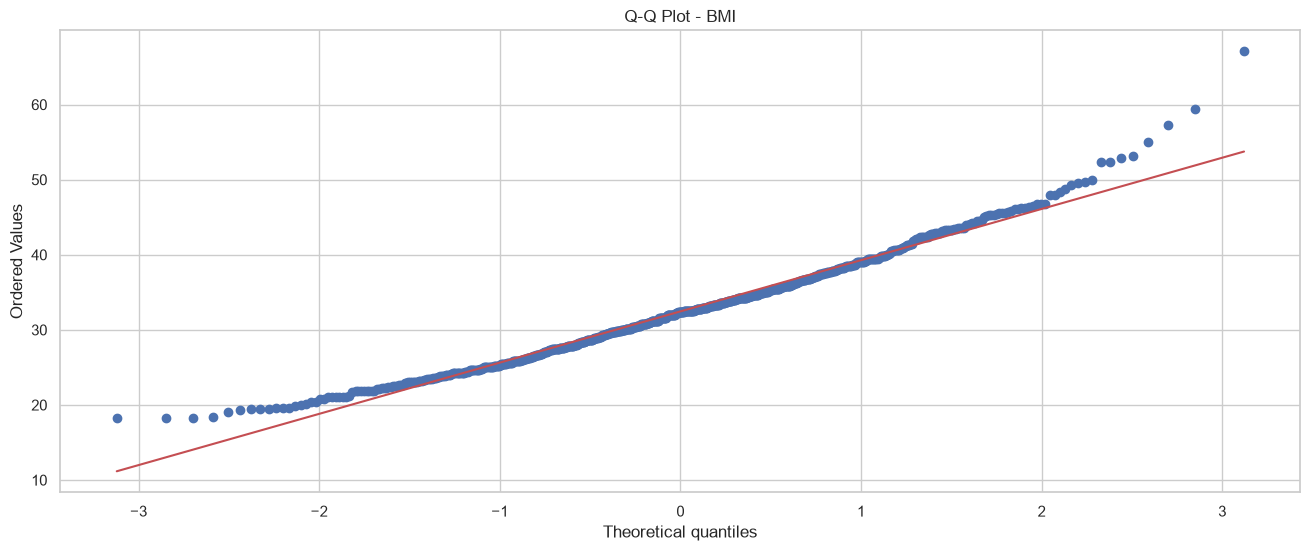

In [140]:
# Q-Q Plot for each selected feature:
plt.figure(figsize=(16,6))
stats.probplot(df["BloodPressure"].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot - Blood Pressure")
plt.show()

plt.figure(figsize=(16,6))
stats.probplot(df["Glucose"], dist="norm", plot=plt)
plt.title("Q-Q Plot - Glucose")
plt.show()

plt.figure(figsize=(16,6))
stats.probplot(df["SkinThickness"], dist="norm", plot=plt)
plt.title("Q-Q Plot - Skin Thickness")
plt.show()

plt.figure(figsize=(16,6))
stats.probplot(df["Insulin"], dist="norm", plot=plt)
plt.title("Q-Q Plot - Insulin")
plt.show()

plt.figure(figsize=(16,6))
stats.probplot(df["BMI"], dist="norm", plot=plt)
plt.title("Q-Q Plot - BMI")
plt.show()

## Task 4 — Bivariate Analysis (15 pts)
Produce:
- A **scatter plot** of `Glucose` vs `Age`, colored by `Outcome`
- A **joint plot** of `BMI` vs `Insulin`
- A **regression plot** of `Glucose` vs `Outcome`

Explain what relationship (if any) each plot reveals.


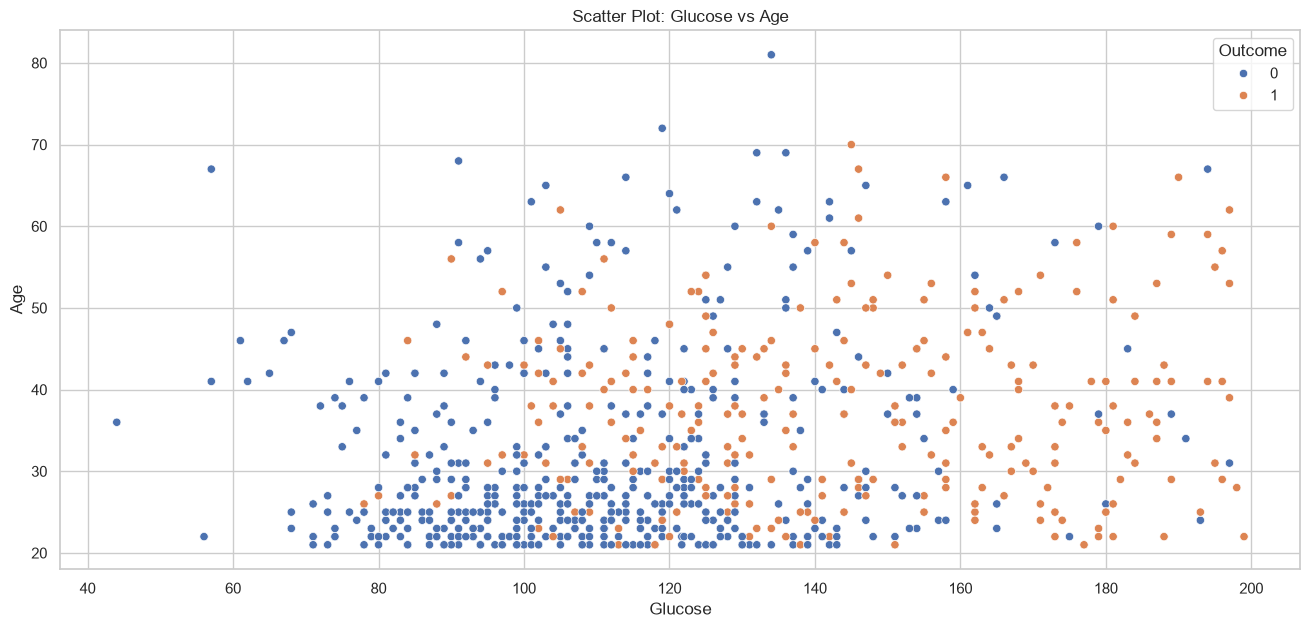

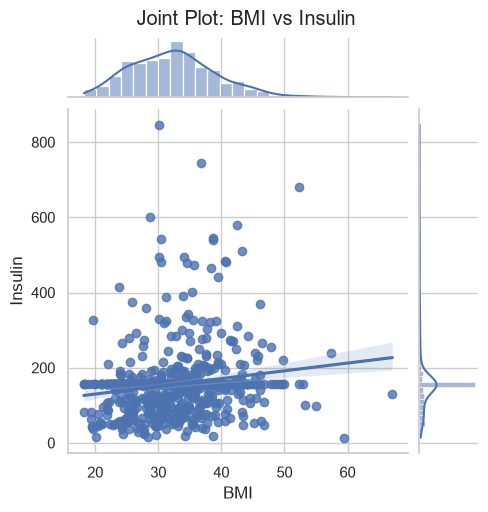

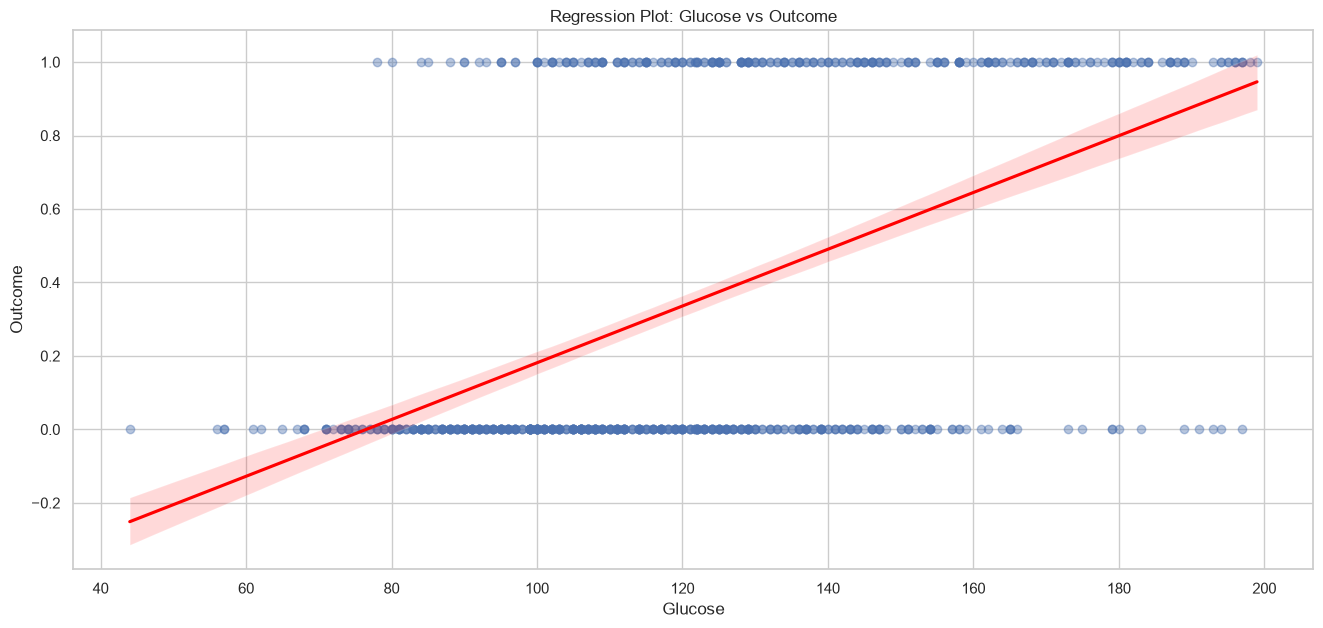

In [138]:
#Task 4
plt.figure(figsize=(16,7))
sns.scatterplot(data=df, x="Glucose", y="Age", hue="Outcome")
plt.title("Scatter Plot: Glucose vs Age")
plt.show()

sns.jointplot(data=df, x="BMI", y="Insulin", kind="reg", height=5)
plt.suptitle("Joint Plot: BMI vs Insulin", y=1.02)
plt.show()

plt.figure(figsize=(16,7))
sns.regplot(
    data=df, 
    x="Glucose", 
    y="Outcome", 
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.title("Regression Plot: Glucose vs Outcome")
plt.show()

## Task 5 — Categorical Visualizations (10 pts)
Produce:
- A **count plot** of the `Outcome` target variable (check for class imbalance — this matters a lot for NN training!)
- A **pie chart** showing the proportion of diabetic vs non-diabetic patients

Comment on whether the classes are balanced and what that means for training a neural network.


Count Plot: Outcome Distribution


C:\Users\gonza\AppData\Local\Temp\ipykernel_26192\273668216.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Outcome", palette="viridis")


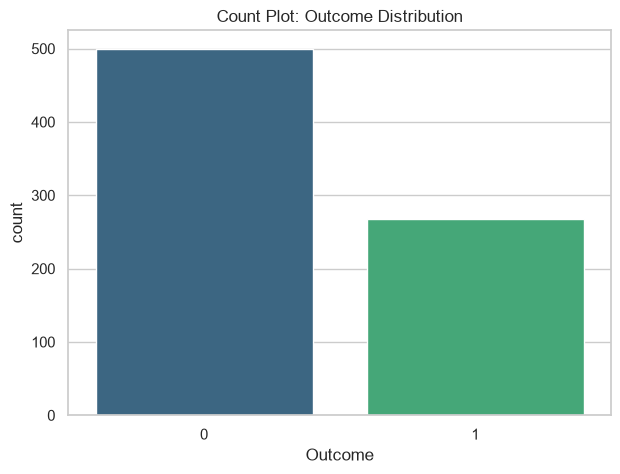

Pie Chart: Outcome/Result


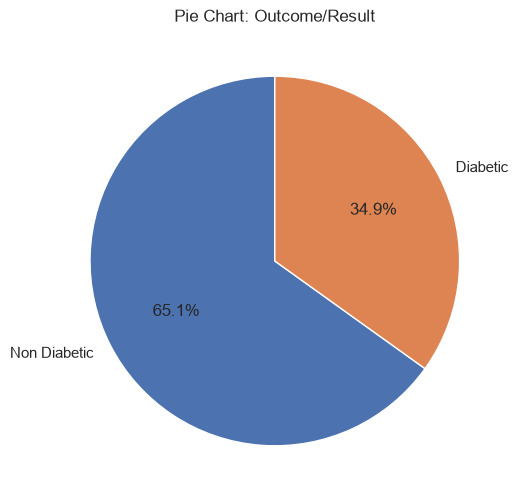

In [139]:
#Task 5
print("=" * 40)
print("Count Plot: Outcome Distribution")
print("=" * 40)
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Outcome", palette="viridis")
plt.title("Count Plot: Outcome Distribution")
plt.show()


print("=" * 40)
print("Pie Chart: Outcome/Result")
print("=" * 40)
label = ["Non Diabetic", "Diabetic"]
plt.figure(figsize=(6,6))
df["Outcome"].value_counts().plot.pie(labels=label, autopct="%1.1f%%", startangle=90)
plt.title("Pie Chart: Outcome/Result")
plt.ylabel("")
plt.show()

## Task 6 — Multivariate Analysis (20 pts)
Produce:
- A **pair plot** of at least 5 features, colored by `Outcome`
- A **facet grid** showing the distribution of `Glucose` split by `Outcome`
- A **correlation heatmap** of all numeric features
- A **3D scatter plot** using any 3 features, colored by `Outcome`

Identify the two features most correlated with `Outcome`.


Pair Plot of the Selected Features:


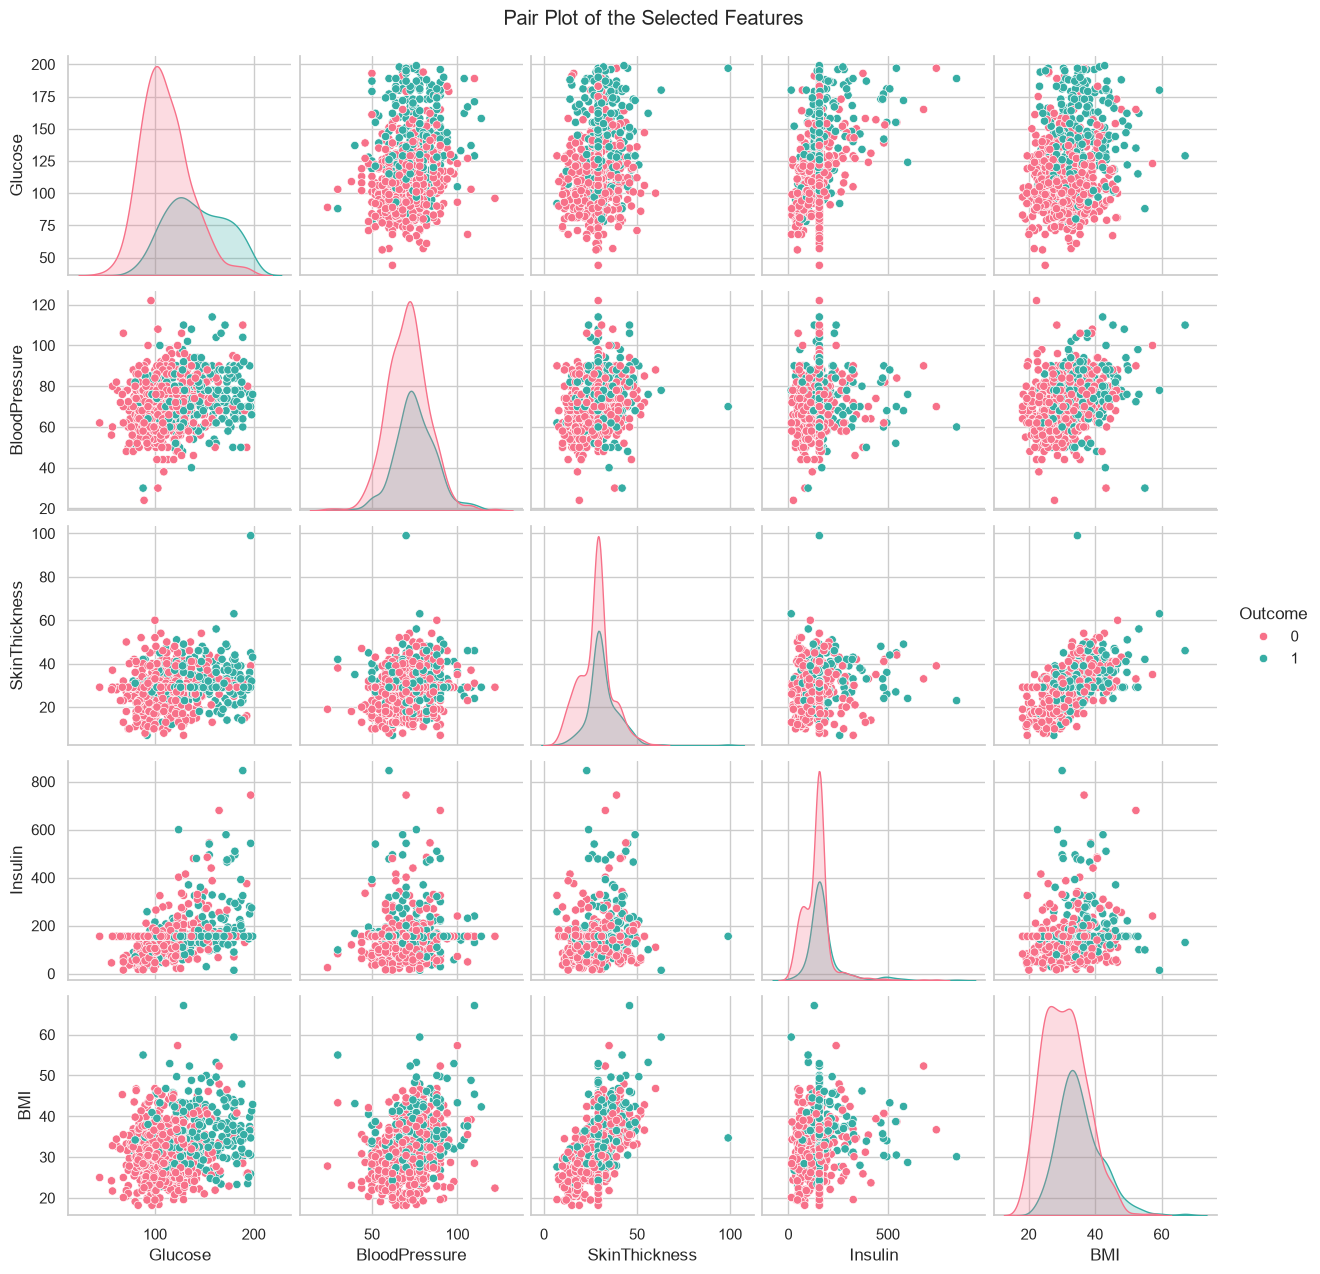

Facet Grid: Glucose Distribution by Outcome


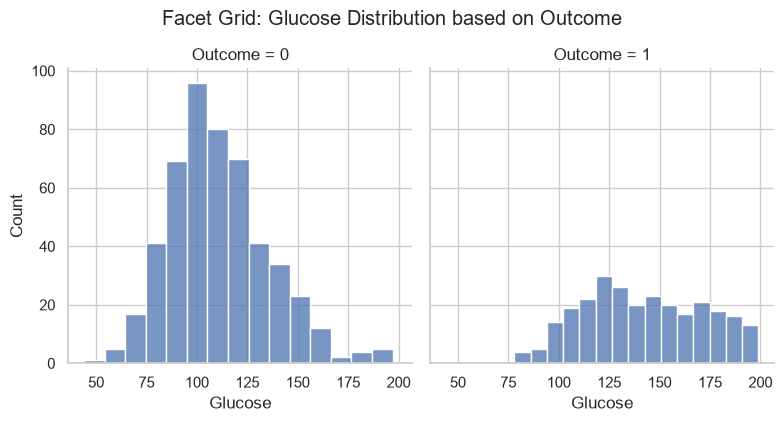

Correlation Heatmap for all variables in the dataset:


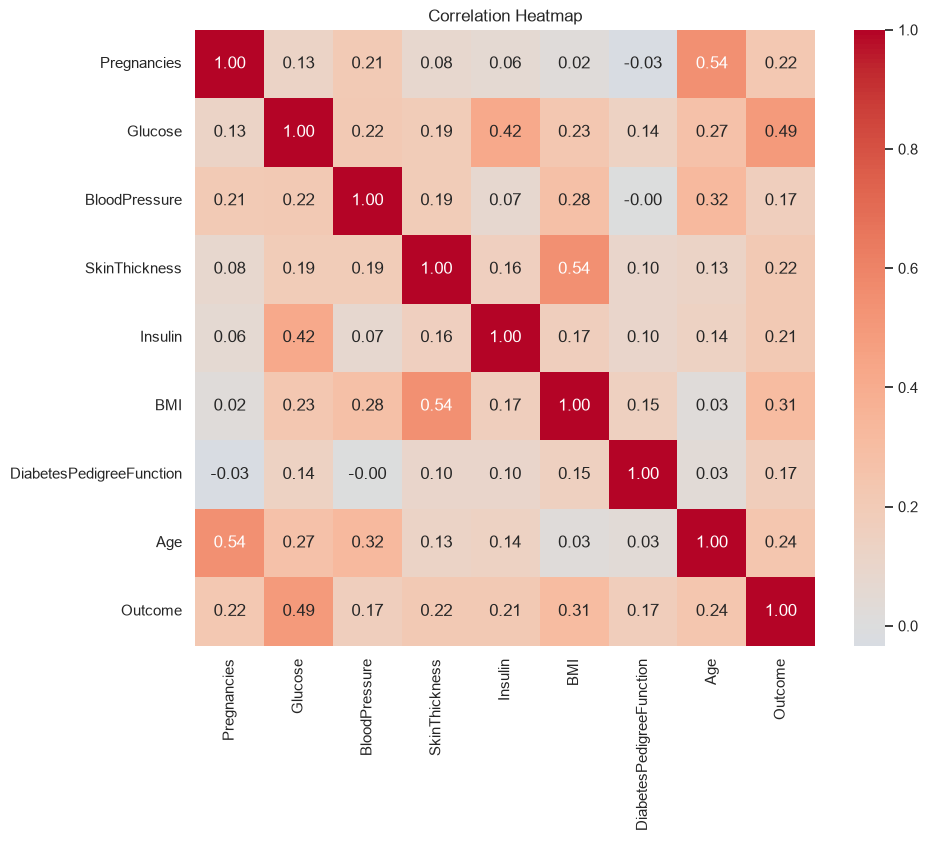

3D Scatter Plot: Insulin vs Skin Thickness vs BMI


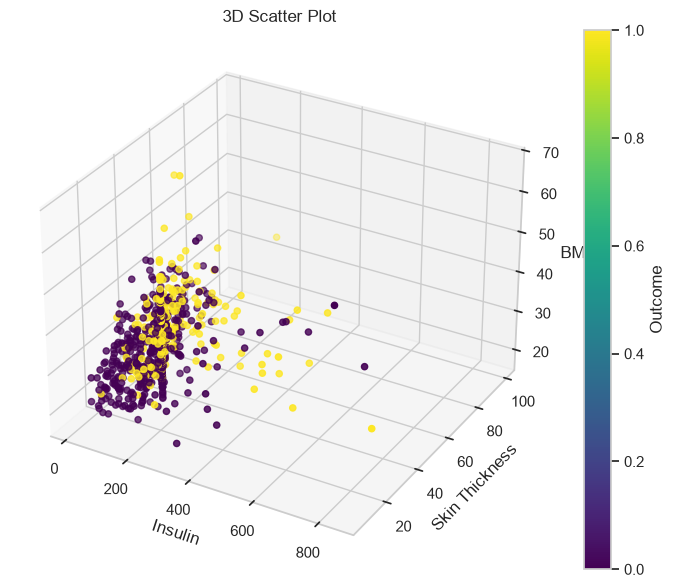

In [144]:
#Task 6
print("=" * 40)
print("Pair Plot of the Selected Features:")
print("=" * 40)
subset_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Outcome"]
sns.pairplot(df[subset_cols], hue="Outcome", palette="husl", diag_kind="kde")
plt.suptitle("Pair Plot of the Selected Features", y=1.02)
plt.show()


print("=" * 45)
print("Facet Grid: Glucose Distribution by Outcome")
print("=" * 45)
g = sns.FacetGrid(df, col="Outcome", height=4)
g.map(sns.histplot, "Glucose", bins=15)
g.fig.suptitle("Facet Grid: Glucose Distribution based on Outcome", y=1.05)
plt.show()

print("=" * 40)
print("Correlation Heatmap for all variables in the dataset:")
print("=" * 40)
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

print("=" * 50)
print("3D Scatter Plot: Insulin vs Skin Thickness vs BMI")
print("=" * 50)
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(df["Insulin"], df["SkinThickness"], df["BMI"], c=df["Outcome"], cmap="viridis")
ax.set_xlabel("Insulin")
ax.set_ylabel("Skin Thickness")
ax.set_zlabel("BMI")
plt.colorbar(sc, label="Outcome")
plt.title("3D Scatter Plot")
plt.show()


---
## Submission Checklist
- All 6 tasks completed with working code and output visible
- Each plot has a title and axis labels
- Written interpretation included under each task
- Notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)

## Grading Rubric (100 pts total)
| Task | Points |
|---|---|
| 1. Data Overview | 15 |
| 2. Missing Value Analysis | 15 |
| 3. Univariate Analysis | 25 |
| 4. Bivariate Analysis | 15 |
| 5. Categorical Visualizations | 10 |
| 6. Multivariate Analysis | 20 |